### Event Log Description

| Column Name | Description | Example Value | Data Type / Potential Values |
|:---|:---|:---|:---|
| **ETA** | Age of the patient | 92 | Integer (0 - 100+) |
| **PATOLOGIA_TRIAGE** | Triage Complaint / Initial Symptom or Pathology | DIFFICOLTÀ RESPIRATORIA (Respiratory difficulty) | Categorical (e.g., DOLORE TORACICO, TRAUMA, FEBBRE) |
| **ESITO_DIMISSIONE** | Discharge Outcome / Destination | DECEDUTO IN PS (Deceased in ER) | Categorical (e.g., DIMESSO, RICOVERATO, TRASFERITO) |
| **ATTRIBUTO** | Event Attribute (Additional context for the activity) | AMBULANZA 118- SENZA MEDICO | Text / Categorical |
| **UNITA** | Hospital Unit / Department | PS (Pronto Soccorso / ER) | Categorical (e.g., PS, RADIOLOGIA, RIANIMAZIONE) |
| **ACCESSO** | Admission Mode / Arrival Method | AMBULANZA 118- SENZA MEDICO (Ambulance without doctor) | Categorical (e.g., MEZZO PROPRIO, ELISOCCORSO) |
| **URGENZA** | Urgency / Priority Level | URGENZA INDIFFERIBILE (Urgent / High priority) | Categorical / Ordinal (e.g., CODICE ROSSO, VERDE, GIALLO) |

| Column Name | Type | Unique Values Found (Italian) | English Description / Translation of Values |
|:---|:---|:---|:---|
| **PATOLOGIA_TRIAGE** | Categorical | • DIFFICOLTÀ RESPIRATORIA (- PED)<br>• FEBBRE (- PED)<br>• TRAUMA (ARTI, TORACICO, CRANICO, VERTEBRALE)<br>• DOLORE (TORACICO, ADDOMINALE, LOMBARE)<br>• DISTURBO NEUROLOGICO / CEFALEA<br>• INTOSSICAZIONE<br>• SINTOMI OSTETRICO-GINECOLOGICI<br>• VERTIGINE / PALPITAZIONI<br>• ALTRO / ALTRI SINTOMI | • Respiratory Difficulty (incl. Pediatric)<br>• Fever (incl. Pediatric)<br>• Trauma (Limbs, Chest, Head, Vertebral)<br>• Pain (Chest, Abdominal, Lower Back)<br>• Neurological Disorder / Headache<br>• Intoxication / Poisoning<br>• Obstetric-Gynecological Symptoms<br>• Vertigo / Palpitations<br>• Other / Miscellaneous symptoms |
| **ESITO_DIMISSIONE** | Categorical | • DIMISSIONE A DOMICILIO<br>• RICOVERO IN REPARTO DI DEGENZA<br>• TRASFERIMENTO AD ALTRO ISTITUTO / TERRITORIALE<br>• DIMISSIONE VOLONTARIA / RIFIUTA RICOVERO<br>• IL PAZIENTE ABBANDONA IL PS (PRIMA DELLA VISITA / IN CORSO DI ACCERTAMENTI)<br>• DECEDUTO IN PS / GIUNTO CADAVERE | • Discharged Home<br>• Admitted to Hospital Ward<br>• Transferred to another facility / local clinic<br>• Voluntary discharge / Refused admission<br>• Patient left ER (before medical check / during clinical exams)<br>• Deceased in ER / Arrived dead |
| **concept:name** | Categorical | • ACCESSO / Triage / VISITA / DIMISSIONE / USCITA<br>• LABORATORIO / TERAPIA / OSSERVAZIONE<br>• RADIOLOGIA (RX, TC, ECOGRAFIA, RM, ANGIO, ECODOPPLER)<br>• CONSULENZA (PNEUMOLOGICA, PEDIATRICA, NEUROLOGICA, CARDIOLOGICA, ORTOPEDICA, GINECOLOGICA, etc.) | • Entry / Triage / Exam / Discharge / Exit<br>• Laboratory / Therapy / Observation (OBI)<br>• Radiology (X-Ray, CT, Ultrasound, MRI, Angio)<br>• Specialist Consultation (Pulmonology, Pediatrics, Neurology, Cardiology, Orthopedics, Ob-Gyn, etc.) |
| **ATTRIBUTO** | Categorical / Text | • Transport: AMBULANZA 118 (CON/SENZA MEDICO), AUTONOMO, ELIAMBULANZA<br>• Triage codes: EMERGENZA, URGENZA (INDIFFERIBILE, DIFFERIBILE, MINORE), NON URGENZA<br>• Lab tests: EMOCROMO, PRELIEVO VENOSO, EMOGASANALISI, TROPONINA T, CREATININA, PCR<br>• Procedures: SUTURA, CATETERISMO, VENTILAZIONE NON INVASIVA, INTUBAZIONE, MEDICAZIONE<br>• Codes: LBR_xxxx (Internal Lab Codes) | • Transport: Ambulance (with/without doctor), Walk-in, Helicopter<br>• Priority: Emergency, Urgent (Non-deferrable, Deferrable, Minor), Non-urgent<br>• Lab tests: Blood count, Venous sample, Blood gas, Troponin T, Creatinine, CRP<br>• Procedures: Sutures, Catheterization, Non-invasive ventilation, Intubation, Dressing |
| **UNITA** | Categorical | • PS (Pronto Soccorso)<br>• OBI (Osservazione Breve Intensiva)<br>• ALTA / MEDIA / BASSA / SALA<br>• Specialists: PEDIATRIA, ORTOPEDIA, OCULISTICA, UROLOGIA, OTORINO, DERMATOLOGIA, OSTETRICIA | • Emergency Room (ER)<br>• Short-Stay Intensive Observation Unit<br>• Acuity/Care levels (High, Medium, Low, Room)<br>• Specialized Units: Pediatrics, Orthopedics, Ophthalmology, Urology, ENT, Dermatology, Ob-Gyn |
| **ACCESSO** | Categorical | • AMBULANZA 118 (SENZA MEDICO / CON MEDICO)<br>• AUTONOMO<br>• ELIAMBULANZA 118<br>• AMBULANZA PRIVATA / PUBBLICA<br>• ALTRO | • 118 Emergency Ambulance (Basic / Advanced Life Support)<br>• Self-arrival / Walk-in<br>• 118 Rescue Helicopter<br>• Private / Public Ambulance<br>• Other |
| **URGENZA** | Categorical | • EMERGENZA<br>• URGENZA INDIFFERIBILE<br>• URGENZA DIFFERIBILE<br>• URGENZA MINORE<br>• NON URGENZA | • Emergency (Red)<br>• Non-deferrable Urgency (Orange/Yellow)<br>• Deferrable Urgency (Green)<br>• Minor Urgency (Blue)<br>• Non-urgent (White) |

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
csv_path = 'C:\\Users\\Pavel\\Desktop\\PROJECTS\\master-thesis\\datasets\\raw\\Emergency.csv'

xes_path = 'C:\\Users\\Pavel\\Desktop\\PROJECTS\\master-thesis\\datasets\\raw\\Emergency.xes'

In [25]:
log_df = pd.read_csv(str(csv_path))

log_df['PATOLOGIA_TRIAGE'] = (
    log_df['PATOLOGIA_TRIAGE']
    .str.replace('DIFFICOLTÃƒÂ€', 'DIFFICOLTÀ')
    .str.strip()
)

log_df.head()

,case:concept:name,ETA,PATOLOGIA_TRIAGE,ESITO_DIMISSIONE,concept:name,ATTRIBUTO,org:resource,UNITA,ACCESSO,URGENZA,start:timestamp,time:timestamp
0,108262,92,DIFFICOLTÀ RESPIRATORIA,DECEDUTO IN PS,ACCESSO,AMBULANZA 118- SENZA MEDICO,3780.0,PS,AMBULANZA 118- SENZA MEDICO,URGENZA INDIFFERIBILE,2024-01-01 00:24:54+00:00,2024-01-01 00:24:54+00:00
1,108262,92,DIFFICOLTÀ RESPIRATORIA,DECEDUTO IN PS,TRIAGE,URGENZA INDIFFERIBILE,3780.0,PS,AMBULANZA 118- SENZA MEDICO,URGENZA INDIFFERIBILE,2024-01-01 00:25:13+00:00,2024-01-01 00:25:16+00:00
2,108262,92,DIFFICOLTÀ RESPIRATORIA,DECEDUTO IN PS,LABORATORIO,EMOGASANALISI ARTERIOSA SISTEMICA,3780.0,PS,AMBULANZA 118- SENZA MEDICO,URGENZA INDIFFERIBILE,2024-01-01 00:30:20+00:00,2024-01-01 00:32:54+00:00
3,108262,92,DIFFICOLTÀ RESPIRATORIA,DECEDUTO IN PS,VISITA,NaN,3971.0,ALTA,AMBULANZA 118- SENZA MEDICO,URGENZA INDIFFERIBILE,2024-01-01 00:32:54+00:00,2024-01-01 01:42:37+00:00
4,108262,92,DIFFICOLTÀ RESPIRATORIA,DECEDUTO IN PS,PRESTAZIONIPS,PRELIEVO VENOSO,3971.0,ALTA,AMBULANZA 118- SENZA MEDICO,URGENZA INDIFFERIBILE,2024-01-01 01:45:02+00:00,2024-01-01 01:45:02+00:00


In [26]:
print(f"{log_df['time:timestamp'].min()} -- {log_df['time:timestamp'].max()}")

2024-01-01 00:24:54+00:00 -- 2025-01-02 13:39:15+00:00


### Observations

#### Pediatric Markers vs. Patient Age (`ETA`)

**Objective:** Validate data consistency by ensuring that entries marked as pediatric in `PATOLOGIA_TRIAGE` (containing the `- PED` suffix) strictly correspond to children/adolescents in the `ETA` (Age) column.

* **Target Suffix:** `- PED` (e.g., `FEBBRE - PED`, `TRAUMA CRANICO - PED`)
* **Expected Rule:** $\text{ETA} \le 16$ years old for all pediatric-labeled rows.
* **Anomaly Threshold:** Any row where `PATOLOGIA_TRIAGE` ends with `- PED` but `ETA` is greater than 16.

In [27]:
ped_mask = log_df['PATOLOGIA_TRIAGE'].str.contains('- PED', na=False)
ped_events = log_df[ped_mask]

age_threshold = 16
anomalies_events = ped_events[ped_events['ETA'] > age_threshold]

total_ped_cases = ped_events['case:concept:name'].nunique()
anomaly_cases = anomalies_events['case:concept:name'].nunique()

print(f'Total unique pediatric-labeled cases: {total_ped_cases}')
print(f'Anomaly Cases Found: {anomaly_cases}')

if anomaly_cases > 0:
    print('\nAnomaly cases:')
    print(
        anomalies_events[
            ['case:concept:name', 'ETA', 'PATOLOGIA_TRIAGE']
        ].drop_duplicates()
    )

Total unique pediatric-labeled cases: 3140
Anomaly Cases Found: 6

Anomaly cases:
        case:concept:name  ETA               PATOLOGIA_TRIAGE
17446              110015   26        DOLORE ADDOMINALE - PED
180225             127430   17                   FEBBRE - PED
296585             140335   17         VOMITO E DIARREA - PED
322323             143118   18  DIFFICOLTÀ RESPIRATORIA - PED
450983             157188   17           TRAUMA CRANICO - PED
515613             164078   17                   FEBBRE - PED


#### Distribution of Triage Pathologies by Month

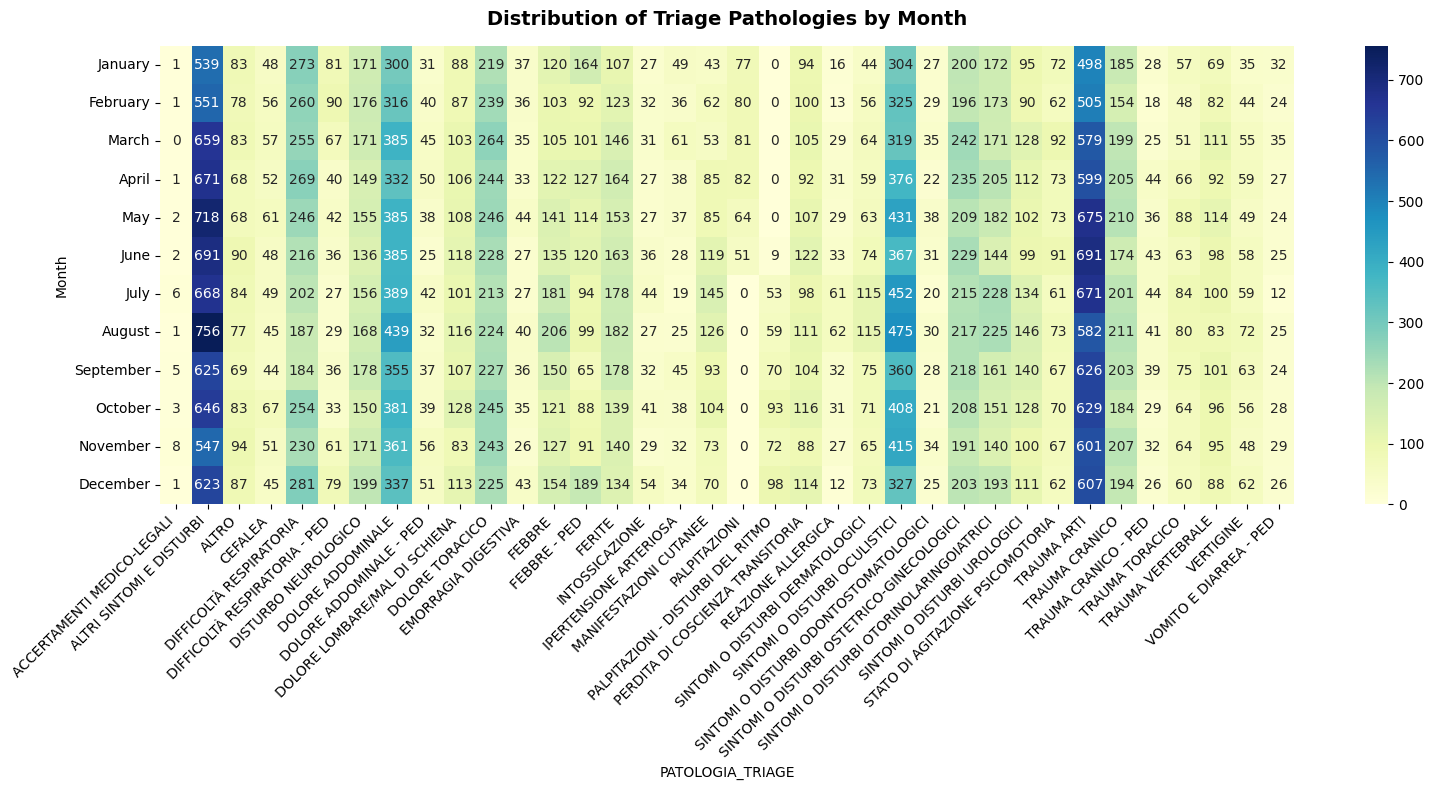

In [28]:
def show_distribution_by_month(log_df):
    log_df['time:timestamp'] = pd.to_datetime(log_df['time:timestamp'])

    log_df['Month'] = log_df['time:timestamp'].dt.strftime('%B')
    months_order = [
        'January',
        'February',
        'March',
        'April',
        'May',
        'June',
        'July',
        'August',
        'September',
        'October',
        'November',
        'December',
    ]

    existing_months = [m for m in months_order if m in log_df['Month'].unique()]

    monthly_matrix = (
        log_df.groupby(['Month', 'PATOLOGIA_TRIAGE'])['case:concept:name']
        .nunique()
        .unstack(fill_value=0)
    )
    monthly_matrix = monthly_matrix.reindex(existing_months)

    plt.figure(figsize=(16, 8))
    sns.heatmap(
        monthly_matrix,
        annot=True,
        fmt='d',
        cmap='YlGnBu',
    )
    plt.title(
        'Distribution of Triage Pathologies by Month',
        fontsize=14,
        fontweight='bold',
        pad=15,
    )
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

show_distribution_by_month(log_df)

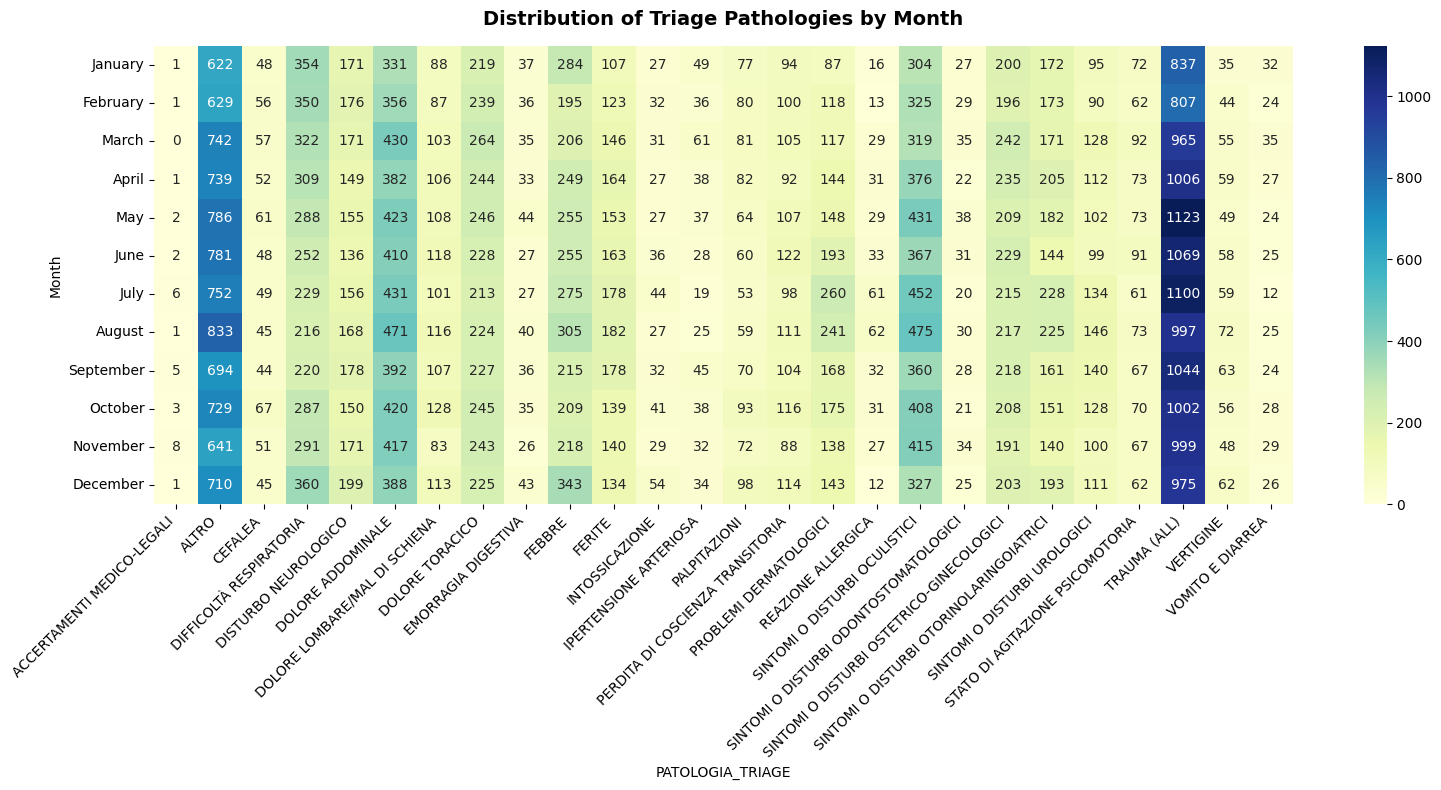

In [29]:
pathology_log_df = log_df.copy()

pathology_mapping = {
    # Likely, changed naming for the same pathology
    'PALPITAZIONI - DISTURBI DEL RITMO': 'PALPITAZIONI',

    # Pediatric and non-pediatric pathologies combined
    'DIFFICOLTÀ RESPIRATORIA - PED': 'DIFFICOLTÀ RESPIRATORIA',
    'FEBBRE - PED': 'FEBBRE',
    'DOLORE ADDOMINALE - PED': 'DOLORE ADDOMINALE',
    'TRAUMA CRANICO - PED': 'TRAUMA (ALL)',
    'VOMITO E DIARREA - PED': 'VOMITO E DIARREA',

    # Trauma pathologies combined
    'TRAUMA ARTI': 'TRAUMA (ALL)',
    'TRAUMA CRANICO': 'TRAUMA (ALL)',
    'TRAUMA TORACICO': 'TRAUMA (ALL)',
    'TRAUMA VERTEBRALE': 'TRAUMA (ALL)',

    # Dermatological pathologies combined
    'SINTOMI O DISTURBI DERMATOLOGICI': 'PROBLEMI DERMATOLOGICI',
    'MANIFESTAZIONI CUTANEE': 'PROBLEMI DERMATOLOGICI',

    # Others
    'ALTRI SINTOMI E DISTURBI': 'ALTRO',
    'ALTRO': 'ALTRO',
}

pathology_log_df['PATOLOGIA_TRIAGE'] = pathology_log_df['PATOLOGIA_TRIAGE'].replace(
    pathology_mapping
)

show_distribution_by_month(pathology_log_df)

- **DIFFICOLTÀ RESPIRATORIA**: peaks in December - February, lowest in July - September
- **PROBLEMI DERMATOLOGICI**: peaks in June - August
- **FEBBRE**: peaks in December, January, August
- **TRAUMA (ALL)**: peaking in May - July
- **DOLORE ADDOMINALE**: relatively stable with peak in May - August
- **INTOSSICAZIONE**: stable with peak in December
- **ALTRO**: relatively stable with peak in May - August

#### Pathologies by Age Group

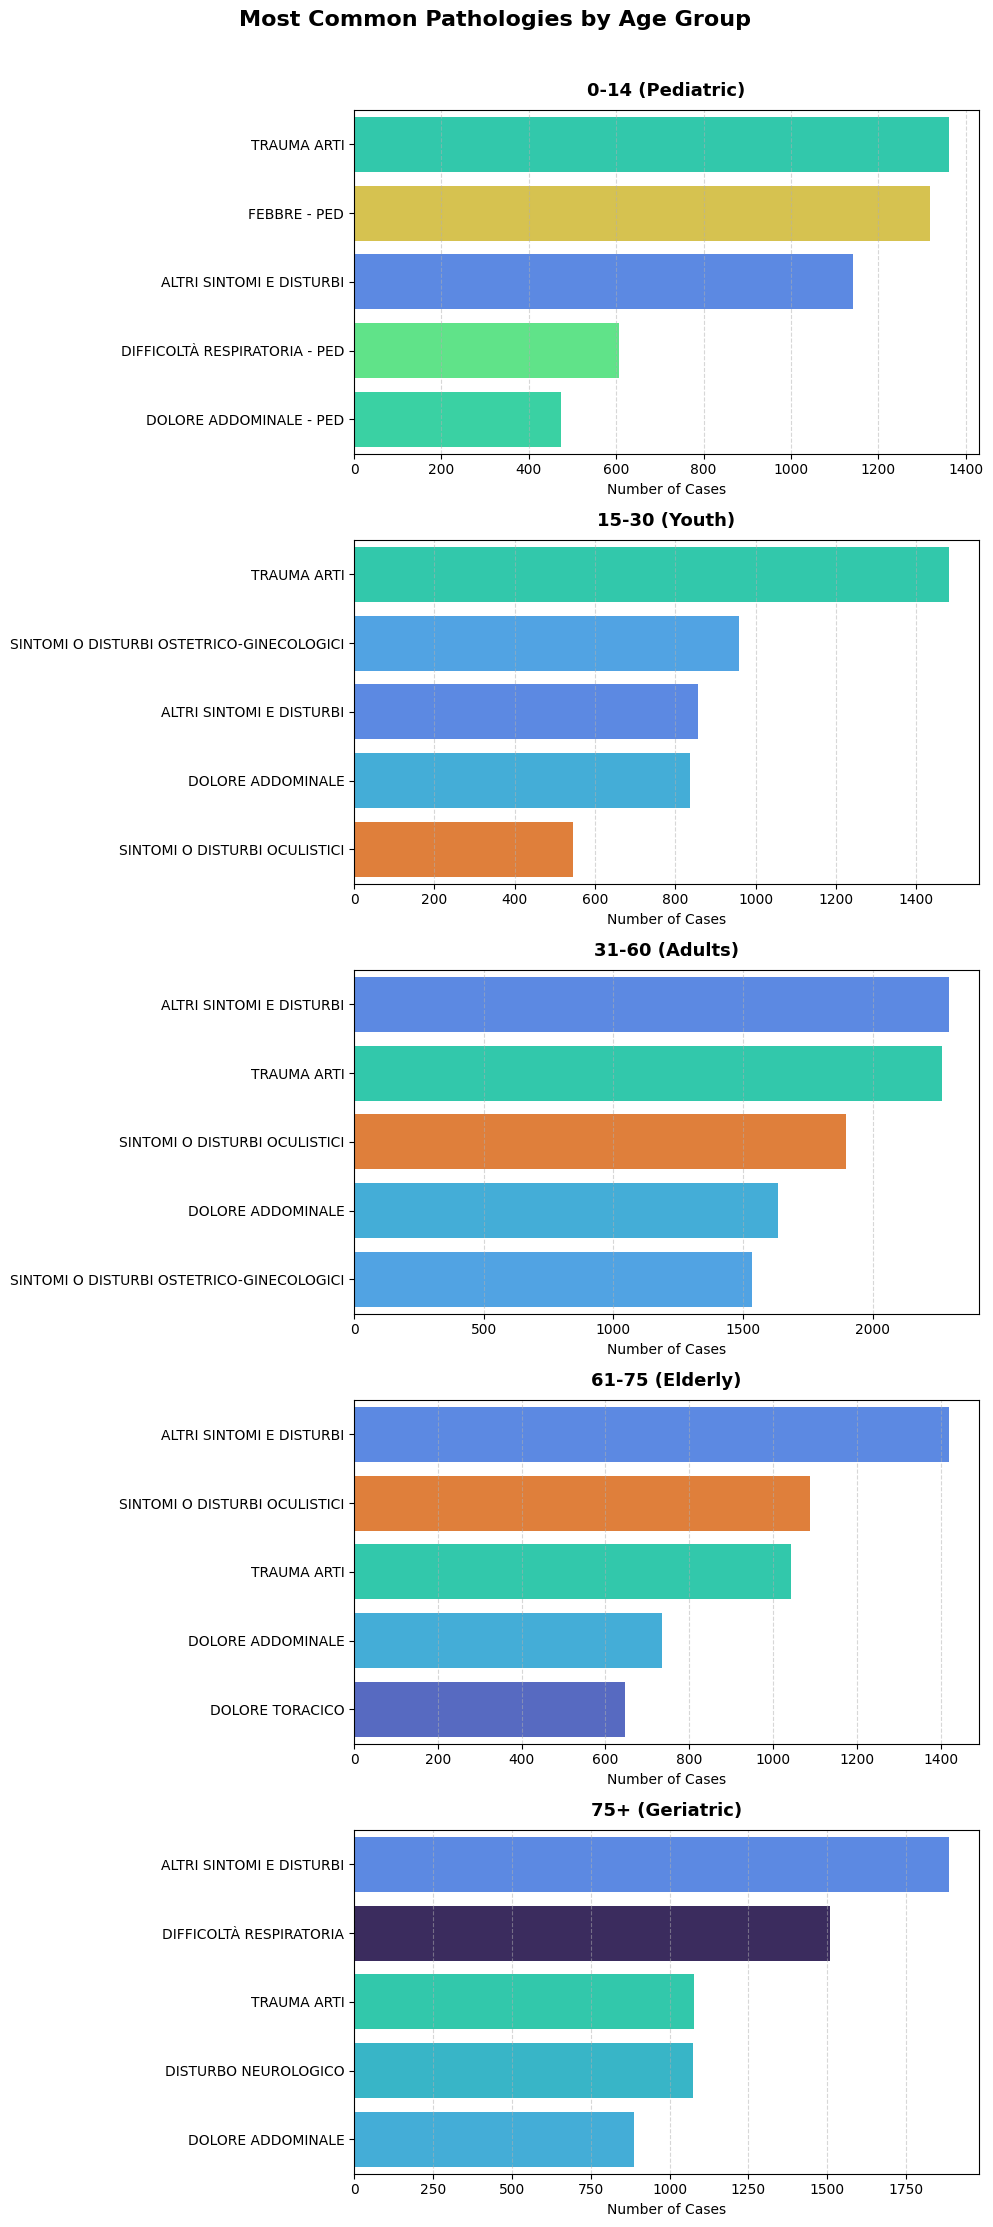

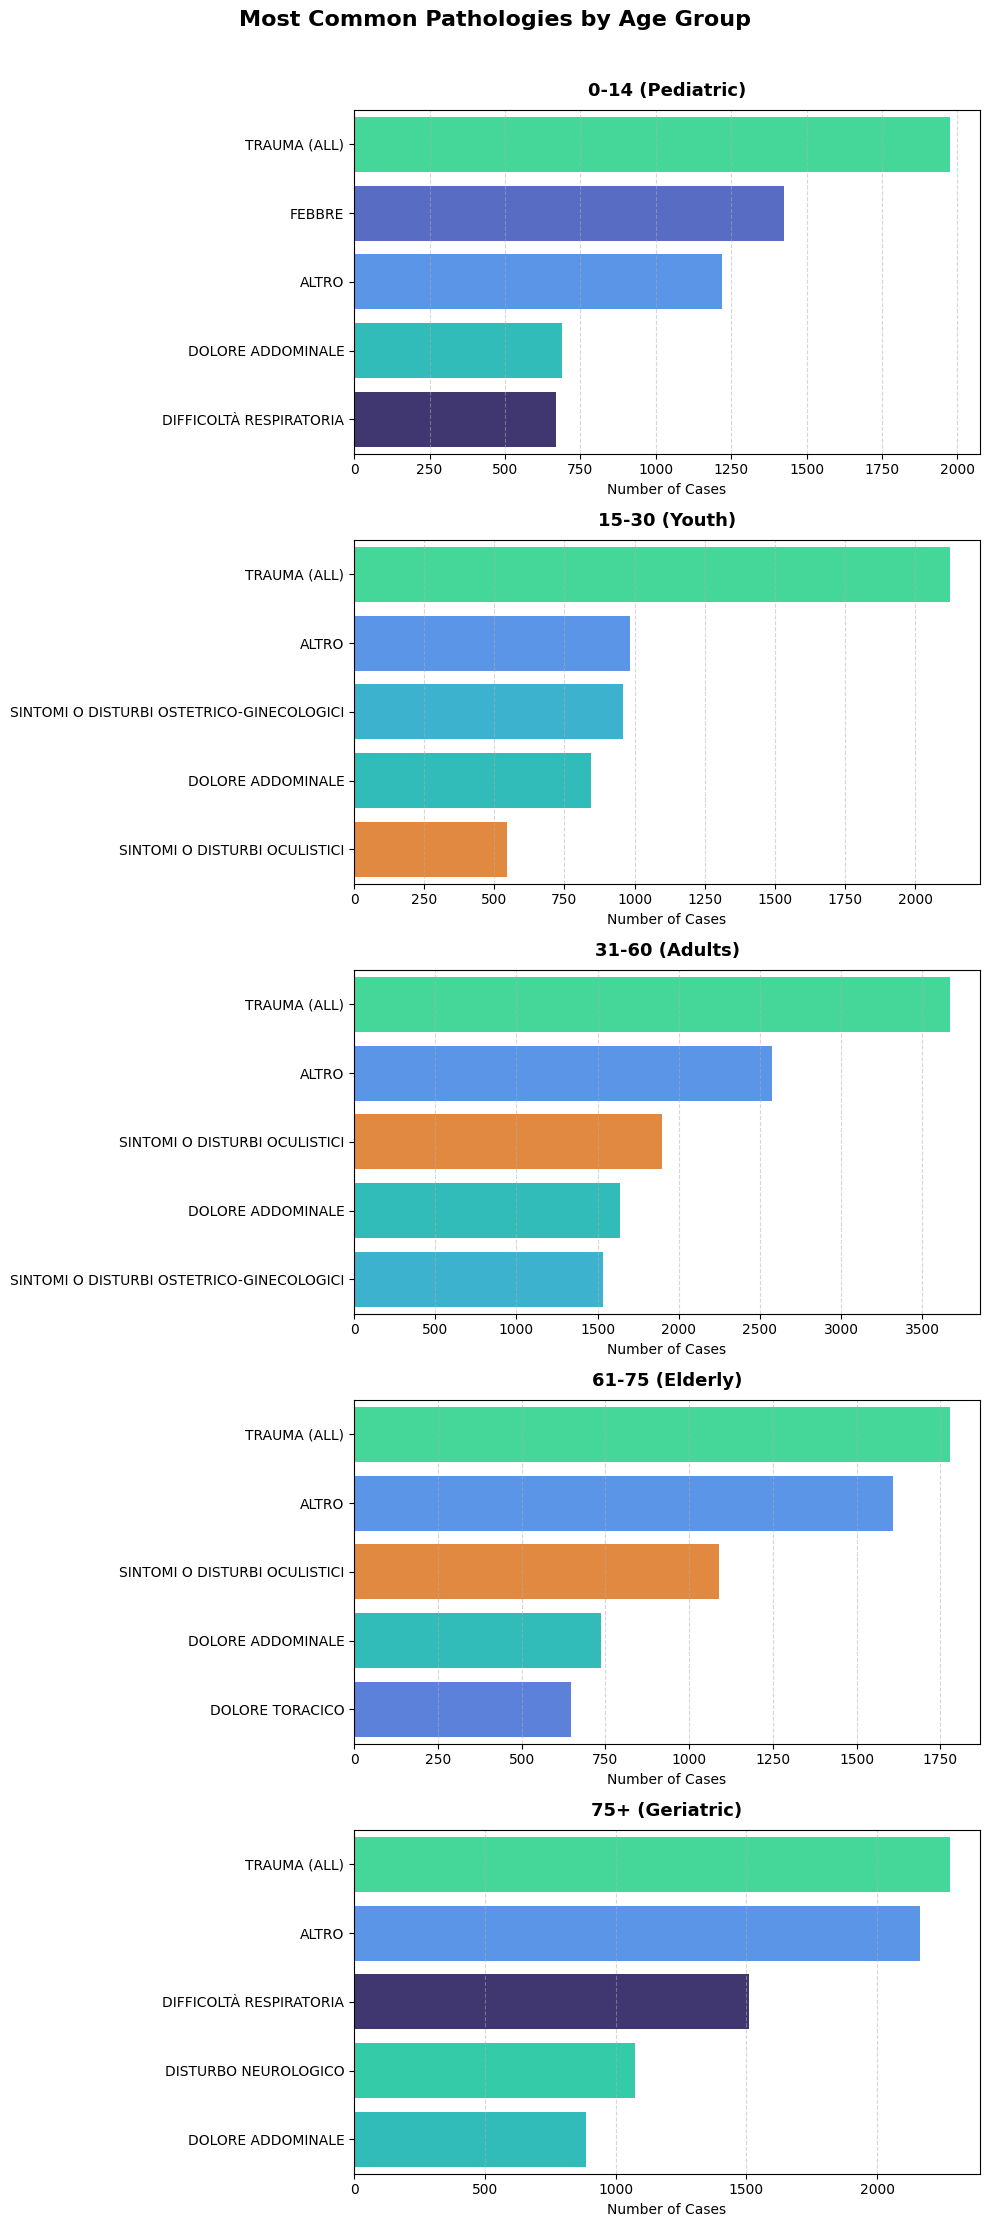

In [33]:
def show_distribution_by_age_group(log_df, top_diseases_num=5):
    def get_age_group(age):
        if age <= 14:
            return '0-14 (Pediatric)'
        elif age <= 30:
            return '15-30 (Youth)'
        elif age <= 60:
            return '31-60 (Adults)'
        elif age <= 75:
            return '61-75 (Elderly)'
        else:
            return '75+ (Geriatric)'

    cases_df = (
        log_df[['case:concept:name', 'ETA', 'PATOLOGIA_TRIAGE']]
        .drop_duplicates()
        .copy()
    )
    cases_df['Age_Group'] = cases_df['ETA'].apply(get_age_group)

    unique_pathologies = cases_df['PATOLOGIA_TRIAGE'].dropna().unique()
    colors = sns.color_palette('turbo', len(unique_pathologies))
    pathology_color_map = dict(zip(unique_pathologies, colors, strict=False))

    age_groups = [
        '0-14 (Pediatric)',
        '15-30 (Youth)',
        '31-60 (Adults)',
        '61-75 (Elderly)',
        '75+ (Geriatric)',
    ]
    fig, axes = plt.subplots(nrows=len(age_groups), ncols=1, figsize=(10, 22))

    for i, group in enumerate(age_groups):
        group_data = cases_df[cases_df['Age_Group'] == group]
        top_diseases = (
            group_data['PATOLOGIA_TRIAGE'].value_counts().head(top_diseases_num)
        )

        if not top_diseases.empty:
            sns.barplot(
                x=top_diseases.values,
                y=top_diseases.index,
                ax=axes[i],
                palette=pathology_color_map,
                hue=top_diseases.index,
                legend=False,
            )
            axes[i].set_title(group, fontsize=13, fontweight='bold', pad=10)
            axes[i].set_xlabel('Number of Cases', fontsize=10)
            axes[i].set_ylabel('')
            axes[i].grid(axis='x', linestyle='--', alpha=0.5)
        else:
            axes[i].text(
                0.5, 0.5, f'No data for group {group}', ha='center', va='center'
            )

    plt.suptitle(
        'Most Common Pathologies by Age Group',
        fontsize=16,
        fontweight='bold',
        y=1.01,
    )
    plt.tight_layout()
    plt.show()


show_distribution_by_age_group(log_df, top_diseases_num=5)
show_distribution_by_age_group(pathology_log_df, top_diseases_num=5)